In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [2]:
data_ncut_weighted = pd.read_csv("gauss_ncut_trafo_100_weighted_mean.csv")
data_ncut_unweighted = pd.read_csv("gauss_ncut_trafo_100_unweighted_mean.csv")
data_rate_weighted= pd.read_csv("gauss_rate_trafo_100_weighted_mean.csv")
data_rate_unweighted= pd.read_csv("gauss_rate_trafo_100_unweighted_mean.csv")

In [3]:
data_ncut_weighted.loc[data_ncut_weighted['alg'] == 'Xcut', 'alg'] = 'XCut'
data_rate_weighted.loc[data_rate_weighted['alg'] == 'Xcut', 'alg'] = 'XCut'

In [4]:
data_ncut_unweighted.loc[data_ncut_unweighted['alg'] == 'Scoreplus', 'alg'] = 'ScorePlus'
data_rate_unweighted.loc[data_rate_unweighted['alg'] == 'Scoreplus', 'alg'] = 'ScorePlus'

# Part 1: mixed gaussian comparison

## Part 1.1: mixed gaussian weighted

In [5]:
alg_colors_weighted_paper = {
    'Xist': 'red',  
    'Leiden': 'orange',
    'KaHIP': 'yellow',
    'Metis': 'purple', 
    'SpecClust': '#5DADE2',  # softer light blue
    'XCut': 'black',
    'Chaco': '#1F3A93',      # deep navy blue
}

In [6]:
# filtering 
data_ncut_weighted_new = data_ncut_weighted[
    (data_ncut_weighted['x'] >= 2) &
    (data_ncut_weighted['values'] != 0) &
    (data_ncut_weighted['alg'] != 'true_results')
]

data_rate_weighted_new = data_rate_weighted[
    (data_rate_weighted['x'] >= 2) &
    (data_rate_weighted['alg'] != 'true_results')
]


In [7]:
def ncut_classif_plot(df_ncut, df_rate, color, name, linewidth=5):
    # --- figure with 1 row, 2 columns ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # wider for two panels

    # =======================
    # Left plot: NCut Value
    # =======================
    ax = axes[0]

    for alg, df_alg in df_ncut.groupby('alg'):
        ax.plot(
            df_alg['x'],
            df_alg['values'],
            color=color.get(alg, None),
            linewidth= linewidth,
            alpha=0.6
        )

    ax.set_xlim(2, 5)
    ax.set_yscale('log')
    #ax.set_yscale('linear')
    ax.tick_params(labelsize=15)

    ax.set_xlabel(r"Distance $\delta$", fontsize= 20)
    ax.set_ylabel("NC value", fontsize= 20)

    ax.text(
        0.5, -0.11,                 
        "(a)",              
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=20
    )

    ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6)
    ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.4)

    # ============================
    # Right plot: Classification rate
    # ============================
    ax = axes[1]

    for alg, df_alg in df_rate.groupby('alg'):
        if alg== "SpecClust":
            ax.plot(df_alg['x'],df_alg['values'],label="SpecClust", color=color.get(alg, None), alpha=0.6, linewidth= linewidth)
        elif alg== "Leiden":
            ax.plot(df_alg['x'],df_alg['values'],label="Leiden (oracle)", color=color.get(alg, None), alpha=0.6, linewidth= linewidth)
        elif alg == "Metis":
            ax.plot(df_alg['x'],df_alg['values'],label="METIS", color=color.get(alg, None), alpha=0.6, linewidth= linewidth)
        else: 
            ax.plot(df_alg['x'],df_alg['values'],label=alg,color=color.get(alg, None),alpha=0.6,linewidth= linewidth)

    
    ax.set_xlim(2, 5)
    #ax.set_yscale('log')
    ax.set_yscale('linear')
    ax.tick_params(labelsize=15)

    ax.set_xlabel(r"Distance $\delta$", fontsize= 20)
    ax.set_ylabel("Classification rate", fontsize= 20)
    
    ax.text(
        0.5, -0.11,                 
        "(b)",               
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=20
    )

    ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6)
    ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.4)

    ax.legend(
        loc='lower right',
        fontsize=20,
        title="Algorithm",
        title_fontsize=20,
        frameon=True,
        fancybox=False,
        framealpha=0.9,
        handlelength=3
    )


    # --- layout & save ---
    plt.tight_layout()
    plt.savefig(f"{name}.pdf")
    plt.show()


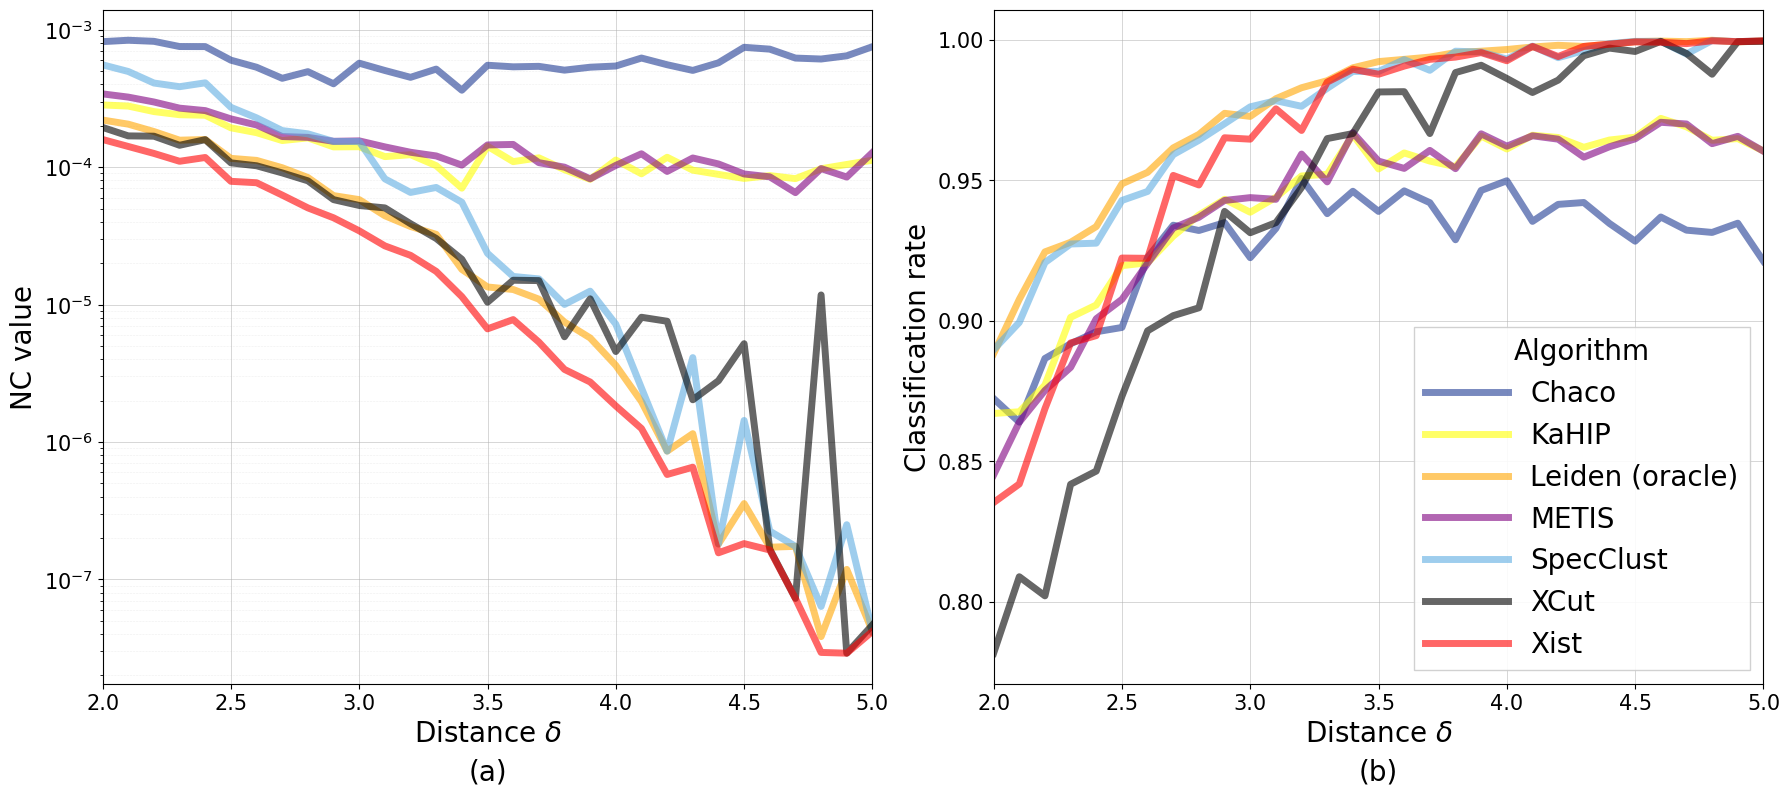

In [8]:
ncut_classif_plot(data_ncut_weighted_new, data_rate_weighted_new ,alg_colors_weighted_paper, "gaussian_mixture_weighed")

## 1.2 mixed gaussian unweighed

In [9]:
alg_colors_unweighted_paper = {
    'Xist': 'red',  
    'ScorePlus': 'green'
}

In [10]:
data_ncut_unweighted_new = data_ncut_unweighted[
    (data_ncut_unweighted['x'] >= 2) &
    (data_ncut_unweighted['values'] != 0) 
]

# --- filtering (same as your Altair prep) ---
data_rate_unweighted_new = data_rate_unweighted[
    (data_rate_unweighted['x'] >= 2) 
]


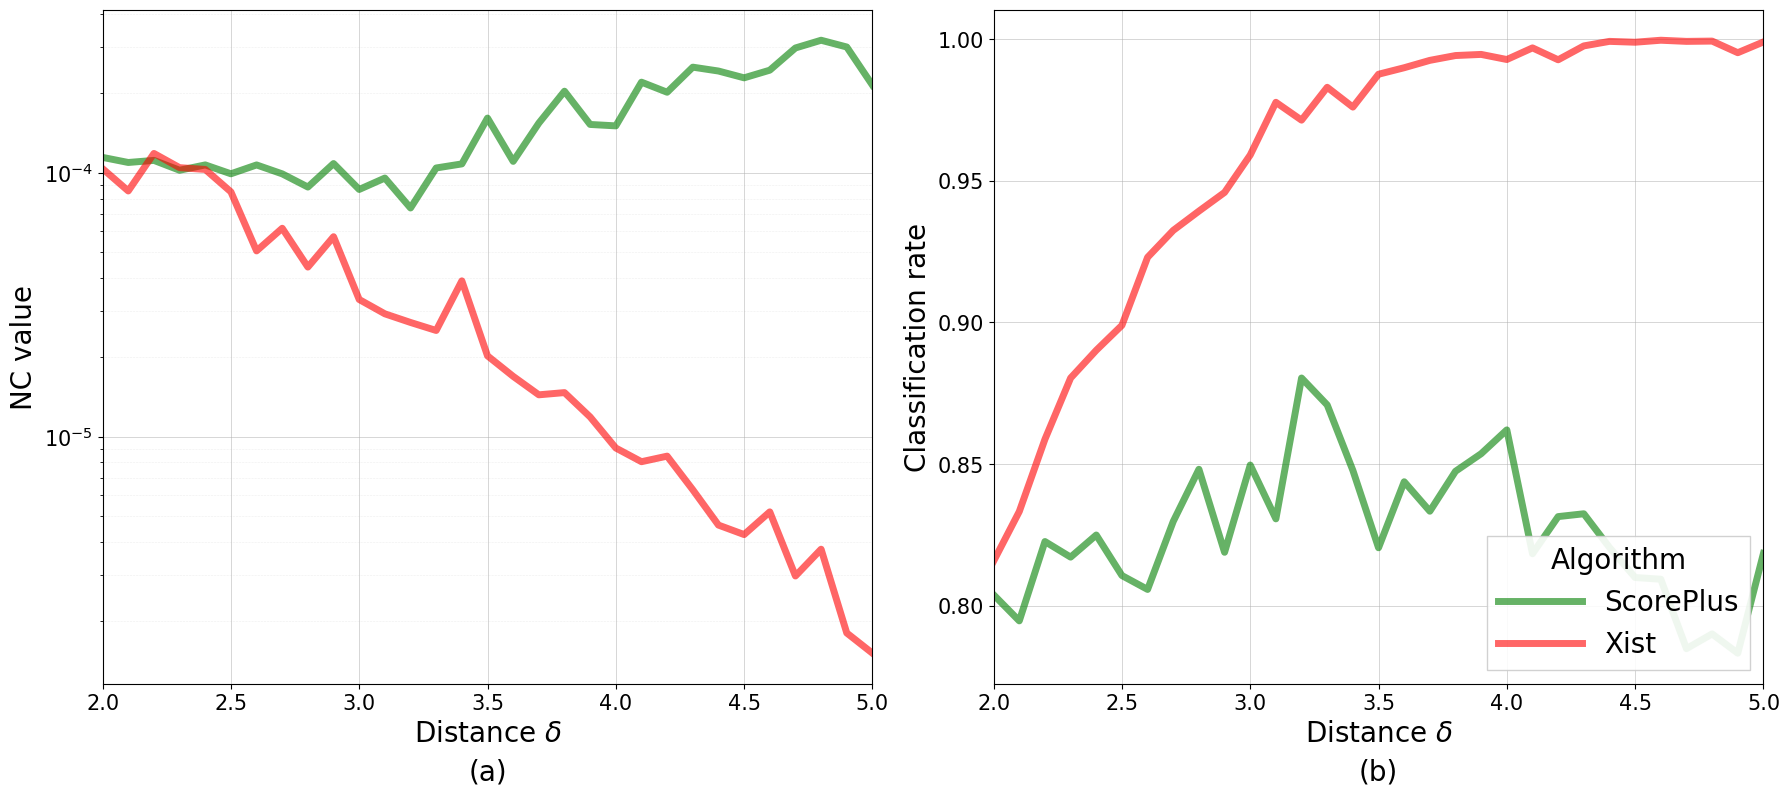

In [11]:
ncut_classif_plot(data_ncut_unweighted_new, data_rate_unweighted_new ,alg_colors_unweighted_paper, "gaussian_mixture_unweighted")

# Part 2: runtime comparison

In [12]:
data_time_weighted= pd.read_csv("nih3t3_timecomp_weighted.csv")
data_time_unweighted= pd.read_csv("nih3t3_timecomp_unweighted.csv")

In [13]:
data_time_weighted.loc[data_time_weighted['alg'] == 'Xcut', 'alg'] = 'XCut'
data_time_unweighted.loc[data_time_unweighted['alg'] == 'Scoreplus', 'alg'] = 'ScorePlus'

In [14]:
def plot_runtimes(df, colors, name):

    df = df.copy()

    df["m"] = df["m"].astype(float)
    ms = sorted(df["m"].unique())
    positions = [m for m in ms]
    algs = list(df["alg"].unique())
    m_min, m_max = df["m"].min(), df["m"].max()
    m_fit = np.linspace(m_min, m_max, 300)
    
    fig, ax = plt.subplots(figsize=(9, 7))


    # Plot the boxplots
    for alg in algs:
        subset = df[df["alg"] == alg]

        box_data = [subset.loc[subset["m"] == m, "time"].dropna() for m in ms]

        ax.boxplot(
            box_data,
            positions=positions,
            patch_artist=True,
            boxprops=dict(facecolor=colors[alg]),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker="o", markersize=3, alpha=0.4),
        )

    # Axes configuration
    ax.set_xlim(7, 29)
    ax.set_yscale("log", base=10)
    ax.set_xlabel("Number of vertices n", fontsize= 20)
    ax.set_ylabel("Running time (sec.)", fontsize= 20)
    ax.set_xticks(positions)
    ax.set_xticklabels([rf"${int(x)}^2$" for x in positions])


    


    # Log-log power-law fits
    #
    # Model:
    #     T(n) = a * n^p
    #
    # Therefore:
    #     log(T) = log(a) + p * log(n)
    #
    # Since n = m^2, we explicitly construct n below.

    alg_params = {}

    for alg in algs:
        df1 = df[df["alg"] == alg].dropna(subset=["m", "time"])

        # Logs require strictly positive values
        #df1 = df1[(df1["m"] > 0) & (df1["time"] > 0)]

        # Actual problem size
        n = df1["m"].to_numpy(dtype=float) ** 2
        t = df1["time"].to_numpy(dtype=float)

        # Transform to log-log space
        log_n = np.log(n)
        log_t = np.log(t)

        # log(T) = p * log(n) + log(a)
        p, log_a = np.polyfit(log_n, log_t, deg=1)

        a = np.exp(log_a)

        # p is now directly the exponent of n
        alg_params[alg] = p

        # Evaluate the fitted model.
        #
        # m_fit is used for the x-coordinate of the plot,
        # but the model itself uses n = m^2.
        n_fit = m_fit**2
        t_fit = a * n_fit**p

        ax.plot(
            m_fit,
            t_fit,
            color=colors[alg],
            linewidth=2.5,
            linestyle="--",
        )


    legend_handles = []
    legend_labels = []


    # Algorithm labels
    for alg, color in colors.items():
        legend_handles.append(
            Line2D( [0], [0], linestyle="", marker="s", markersize=10, markerfacecolor=color, markeredgecolor="black"))

        if alg == "Xvst":
            legend_labels.append(rf"$\mathrm{{Basic \; Xvist}}$")
        else:
            legend_labels.append(rf"$\mathrm{{{alg}}}$")



    # labels line
    for alg, color in colors.items():
        legend_handles.append(
            Line2D( [0], [0.5],  color=color, linestyle="--", linewidth=2) )
        legend_labels.append(  rf"$n^{{{alg_params[alg]:.2f}}}$")



    ax.legend(
        legend_handles,
        legend_labels,
        ncol=2,
        title=r"$\bf{Algorithm}\qquad\bf{Runtime}$",
        columnspacing=1.8,
        handlelength=2.5,
        handleheight=1.9,
        labelspacing=0.8,
        loc="upper left",
        frameon=True,
    )



    # Apply layout BEFORE saving
    plt.tight_layout()
    plt.savefig(f"{name}.pdf", bbox_inches="tight")
    plt.show()

## Part 2.1.1 runtime comparison weighted - including Xcut and Chaco

In [15]:
alg_colors_weighted_runtime = {
    'Xist': 'red',  
    'Leiden': 'orange',
    'KaHIP': 'yellow',
    'METIS': 'purple', 
    'SpecClust': 'blue',
    'XCut': 'black',
    'Chaco': 'green',
    'Xvst': 'gray',
}

In [16]:
#plot_runtimes(data_time_weighted, alg_colors_weighted_runtime, "nih3t3_runtime_comparison_weighted_all_old")

## Part 2.1.2 runtime comparison weighted - excluding Xcut and Chaco¶

In [17]:
alg_colors_weighted_runtime_paper = {
    'Xist': 'red',  
    'Leiden': 'orange',
    'KaHIP': 'yellow',
    'METIS': 'purple', 
    'SpecClust': 'blue',
    'Xvst': 'gray',
}

In [18]:
data_time_weighted_paper = data_time_weighted[data_time_weighted['alg'] != 'Chaco']
data_time_weighted_paper = data_time_weighted_paper[data_time_weighted_paper['alg'] != 'XCut']

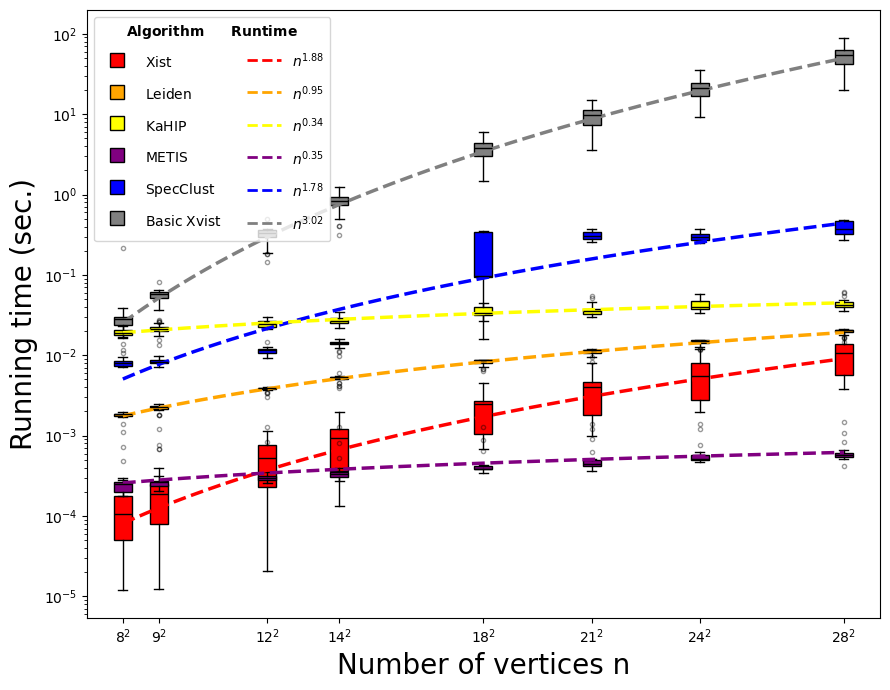

In [19]:
plot_runtimes(data_time_weighted_paper, alg_colors_weighted_runtime_paper, "nih3t3_runtime_comparison_weighted_wo_Chaco_xcut")

## Part 2.2 runtime comparison unweighed

In [20]:
alg_colors_unweighted_runtime = {
    'Xist': 'red',  
    'ScorePlus': 'green',
    'Xvst': 'blue',  
}

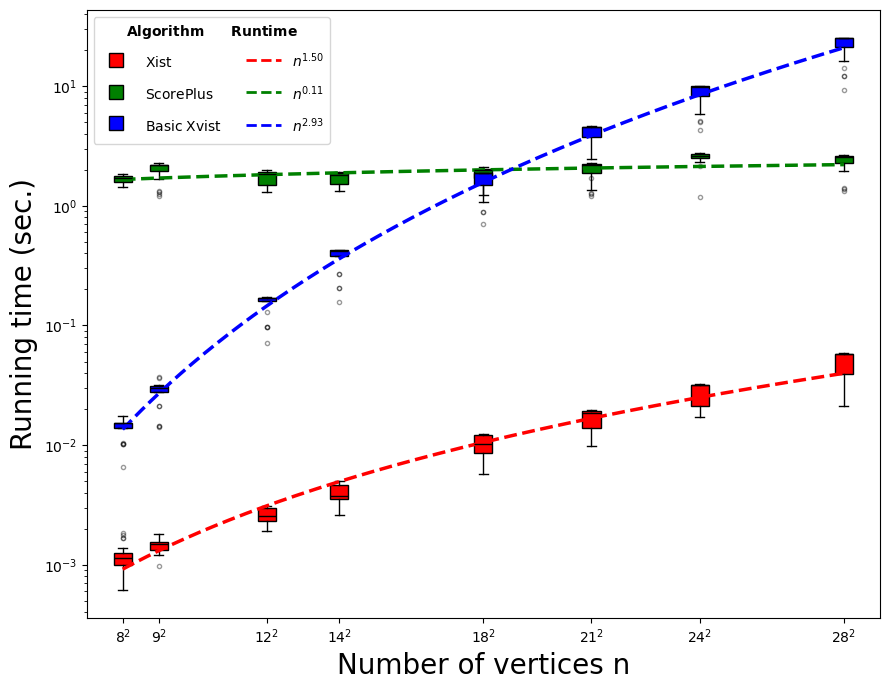

In [21]:
plot_runtimes(data_time_unweighted, alg_colors_unweighted_runtime,  "nih3t3_runtime_comparison_unweighted_new")